###    import  the  libaraies  

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported")

print(f"   LightGBM version : {lgb.__version__}")
print(f"   xgboost version : {xgb.__version__}")

✅ All libraries imported
   LightGBM version : 4.6.0
   xgboost version : 2.0.3


### Load Feature Engineered Data

In [13]:
df = pd.read_parquet('../data/processed/train_features.parquet')

print(f"✅ Data loaded")
print(f"   Shape      : {df.shape}")
print(f"   Fraud rate : {df['isFraud'].mean()*100:.2f}%")
print(f"   Fraud count: {df['isFraud'].sum():,}")
print(f"   Legit count: {(df['isFraud']==0).sum():,}")

✅ Data loaded
   Shape      : (590540, 236)
   Fraud rate : 3.50%
   Fraud count: 20,663
   Legit count: 569,877


In [14]:
df.head() 

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,...,hour,day_of_week,is_night,is_weekend,amt_log,is_round_amount,amt_zscore_card,card1_count,card2_count,card_combo_count,p_email_count,r_email_count,email_domain_match,addr_match,addr1_count,ProductCD_freq,card4_freq,card6_freq,P_emaildomain_freq,M1_freq,M2_freq,M3_freq,M4_freq,M6_freq,card_combo_freq
0,2987000,0,86400,68.5,13926,-999.0,150.0,142.0,315.0,87.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,...,0.000000,1,1,0,4.241327,0,-0.763675,43,-999.0,6,-999.0,0,0,0,23078.0,439670,6651.0,148986.0,-999.0,319415.0,285468.0,251731.0,59865.0,193324.0,6
1,2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,87.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.000278,1,1,0,3.401197,1,-0.445943,683,3056.0,678,228355.0,0,0,0,42751.0,439670,189217.0,148986.0,228355.0,-999.0,-999.0,-999.0,196405.0,193324.0,678
2,2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,87.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.019167,1,1,0,4.094345,1,-0.379666,1108,38145.0,1104,5096.0,0,0,0,26287.0,439670,384767.0,439938.0,5096.0,319415.0,285468.0,251731.0,196405.0,227856.0,1104
3,2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,87.0,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,...,0.027500,1,1,0,3.931826,1,-0.380953,4209,6137.0,4197,100934.0,0,0,0,9478.0,439670,189217.0,439938.0,100934.0,-999.0,-999.0,-999.0,196405.0,227856.0,4197
4,2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,87.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.029444,1,1,0,3.931826,1,-0.829466,18,14541.0,18,228355.0,0,0,0,3581.0,33024,189217.0,148986.0,228355.0,-999.0,-999.0,-999.0,-999.0,-999.0,18


### Prepare Features and Target    

In [15]:
# Columns to drop
drop_cols = [
    'TransactionID',
    'isFraud',
    'TransactionDT',
    'card_combo',
]

# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['isFraud']

# Fix infinity and extreme values right away
X = X.replace([np.inf, -np.inf], np.nan).fillna(-999)
X = X.clip(-1e9, 1e9)

# Make sure all columns are numeric
X = X.select_dtypes(include=np.number)

print(f"✅ Features and target prepared")
print(f"   X shape  : {X.shape}")
print(f"   y shape  : {y.shape}")
print(f"   Features : {X.shape[1]} columns")
print(f"   Inf values remaining : {np.isinf(X).sum().sum()}")
print(f"   NaN values remaining : {X.isnull().sum().sum()}")

✅ Features and target prepared
   X shape  : (590540, 233)
   y shape  : (590540,)
   Features : 233 columns
   Inf values remaining : 0
   NaN values remaining : 0


###  Train / Validation / Test Split      

In [16]:
# First split — 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split — 50/50 of temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"✅ Data split complete")
print(f"   Train : {X_train.shape[0]:,} rows | fraud: {y_train.mean()*100:.2f}%")
print(f"   Val   : {X_val.shape[0]:,} rows | fraud: {y_val.mean()*100:.2f}%")
print(f"   Test  : {X_test.shape[0]:,} rows | fraud: {y_test.mean()*100:.2f}%")

✅ Data split complete
   Train : 413,378 rows | fraud: 3.50%
   Val   : 88,581 rows | fraud: 3.50%
   Test  : 88,581 rows | fraud: 3.50%


###  Handle Class Imbalance with SMOTE

In [17]:
print(f"Before SMOTE:")
print(f"   Train fraud : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"   Train legit : {(y_train==0).sum():,}")

# Verify no inf/nan before SMOTE
assert not np.isinf(X_train.values).any(), "Infinity found in X_train!"
assert not np.isnan(X_train.values).any(), "NaN found in X_train!"

over  = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

pipeline = ImbPipeline([('over', over), ('under', under)])
X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE + Undersampling:")
print(f"   Train fraud : {y_train_res.sum():,} ({y_train_res.mean()*100:.2f}%)")
print(f"   Train legit : {(y_train_res==0).sum():,}")
print(f"   New shape   : {X_train_res.shape}")
print("✅ SMOTE complete")

Before SMOTE:
   Train fraud : 14,464 (3.50%)
   Train legit : 398,914

After SMOTE + Undersampling:
   Train fraud : 39,891 (33.33%)
   Train legit : 79,782
   New shape   : (119673, 233)
✅ SMOTE complete


### Experiment Tracker

In [18]:
os.makedirs('../models', exist_ok=True)

experiment_log = []

def log_experiment(run_name, params, metrics):
    """Save experiment results to a JSON file"""
    run = {
        'run_name' : run_name,
        'params'   : params,
        'metrics'  : metrics
    }
    experiment_log.append(run)
    with open('../models/experiment_log.json', 'w') as f:
        json.dump(experiment_log, f, indent=2)
    print(f"✅ Run '{run_name}' logged")
    for k, v in metrics.items():
        print(f"   {k} : {v}")

print("✅ Experiment tracker ready")

✅ Experiment tracker ready


In [19]:
def evaluate_model(model, X_val, y_val, model_name="Model"):
    """
    AUC-ROC : overall ranking ability      (target >0.90)
    AUC-PR  : better for imbalanced data   (target >0.70)
    """
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc_roc = roc_auc_score(y_val, y_prob)
    auc_pr  = average_precision_score(y_val, y_prob)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Results")
    print(f"{'='*50}")
    print(f"  AUC-ROC : {auc_roc:.4f}   (target >0.90)")
    print(f"  AUC-PR  : {auc_pr:.4f}   (target >0.70)")
    print(f"\nClassification Report:")
    print(classification_report(
        y_val, y_pred,
        target_names=['Legitimate', 'Fraud']
    ))

    return auc_roc, auc_pr, y_prob

print("✅ Evaluation function ready")

✅ Evaluation function ready


###  Train XGBoost Model

In [20]:
print("Training XGBoost... (3–5 minutes)\n")

xgb_params = {
    'n_estimators'     : 500,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 10,
    'eval_metric'      : 'auc',
    'random_state'     : 42,
    'n_jobs'           : -1,
    'tree_method'      : 'hist',
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    verbose=100
)

auc_roc_xgb, auc_pr_xgb, xgb_probs = evaluate_model(
    xgb_model, X_val, y_val, "XGBoost"
)

log_experiment("xgboost_baseline", xgb_params, {
    'auc_roc' : round(auc_roc_xgb, 4),
    'auc_pr'  : round(auc_pr_xgb, 4)
})

Training XGBoost... (3–5 minutes)

[0]	validation_0-auc:0.81082
[100]	validation_0-auc:0.89392
[200]	validation_0-auc:0.91024
[300]	validation_0-auc:0.92048
[400]	validation_0-auc:0.92826
[499]	validation_0-auc:0.93320

  XGBoost — Results
  AUC-ROC : 0.9332   (target >0.90)
  AUC-PR  : 0.6368   (target >0.70)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98     85481
       Fraud       0.57      0.62      0.60      3100

    accuracy                           0.97     88581
   macro avg       0.78      0.80      0.79     88581
weighted avg       0.97      0.97      0.97     88581

✅ Run 'xgboost_baseline' logged
   auc_roc : 0.9332
   auc_pr : 0.6368


### Train LightGBM Model   

In [21]:
print("Training LightGBM... (2–3 minutes)\n")

lgb_params = {
    'n_estimators'      : 500,
    'max_depth'         : 6,
    'learning_rate'     : 0.05,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'min_child_samples' : 20,
    'random_state'      : 42,
    'n_jobs'            : -1,
    'verbose'           : -1,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

auc_roc_lgb, auc_pr_lgb, lgb_probs = evaluate_model(
    lgb_model, X_val, y_val, "LightGBM"
)

log_experiment("lightgbm_baseline", lgb_params, {
    'auc_roc' : round(auc_roc_lgb, 4),
    'auc_pr'  : round(auc_pr_lgb, 4)
})

Training LightGBM... (2–3 minutes)

[100]	valid_0's binary_logloss: 0.170791
[200]	valid_0's binary_logloss: 0.147064
[300]	valid_0's binary_logloss: 0.134991
[400]	valid_0's binary_logloss: 0.126793
[500]	valid_0's binary_logloss: 0.121533

  LightGBM — Results
  AUC-ROC : 0.9311   (target >0.90)
  AUC-PR  : 0.6350   (target >0.70)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98     85481
       Fraud       0.58      0.61      0.60      3100

    accuracy                           0.97     88581
   macro avg       0.78      0.80      0.79     88581
weighted avg       0.97      0.97      0.97     88581

✅ Run 'lightgbm_baseline' logged
   auc_roc : 0.9311
   auc_pr : 0.635


### Compare Both Models   

In [22]:
print("=" * 50)
print("  MODEL COMPARISON")
print("=" * 50)
print(f"  {'Model':<15} {'AUC-ROC':<12} {'AUC-PR'}")
print(f"  {'-'*40}")
print(f"  {'XGBoost':<15} {auc_roc_xgb:<12.4f} {auc_pr_xgb:.4f}")
print(f"  {'LightGBM':<15} {auc_roc_lgb:<12.4f} {auc_pr_lgb:.4f}")
print("=" * 50)

if auc_roc_xgb >= auc_roc_lgb:
    best_model = xgb_model
    best_name  = "XGBoost"
    best_probs = xgb_probs
    best_auc   = auc_roc_xgb
else:
    best_model = lgb_model
    best_name  = "LightGBM"
    best_probs = lgb_probs
    best_auc   = auc_roc_lgb

print(f"\n🏆 Best model : {best_name}  (AUC-ROC: {best_auc:.4f})")

  MODEL COMPARISON
  Model           AUC-ROC      AUC-PR
  ----------------------------------------
  XGBoost         0.9332       0.6368
  LightGBM        0.9311       0.6350

🏆 Best model : XGBoost  (AUC-ROC: 0.9332)


###  ROC and Precision-Recall Curves   

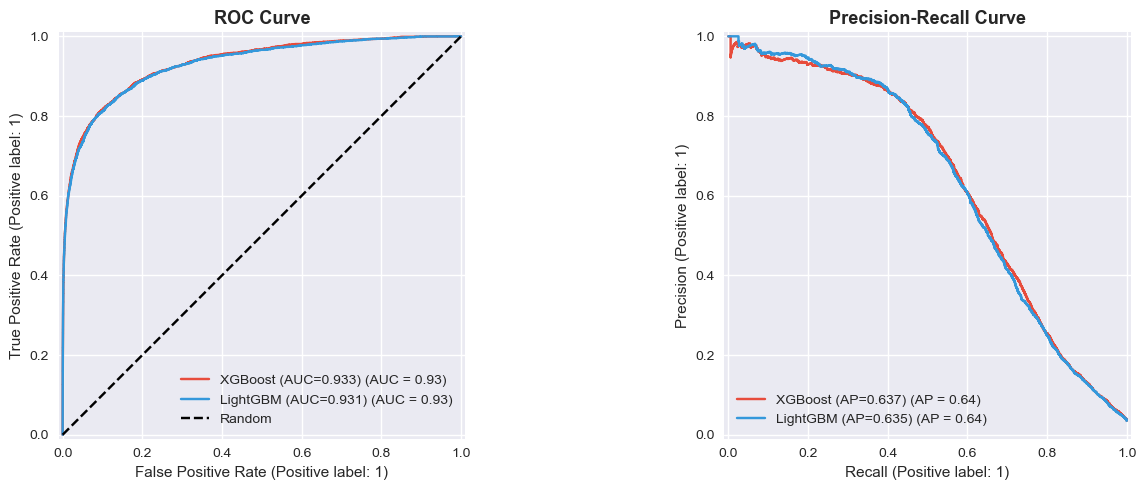

✅ Curves saved


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_val, xgb_probs,
    name=f"XGBoost (AUC={auc_roc_xgb:.3f})",
    ax=axes[0], color='#e74c3c'
)
RocCurveDisplay.from_predictions(
    y_val, lgb_probs,
    name=f"LightGBM (AUC={auc_roc_lgb:.3f})",
    ax=axes[0], color='#3498db'
)
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_val, xgb_probs,
    name=f"XGBoost (AP={auc_pr_xgb:.3f})",
    ax=axes[1], color='#e74c3c'
)
PrecisionRecallDisplay.from_predictions(
    y_val, lgb_probs,
    name=f"LightGBM (AP={auc_pr_lgb:.3f})",
    ax=axes[1], color='#3498db'
)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curves saved")   

###  Confusion Matrix on Test Set   

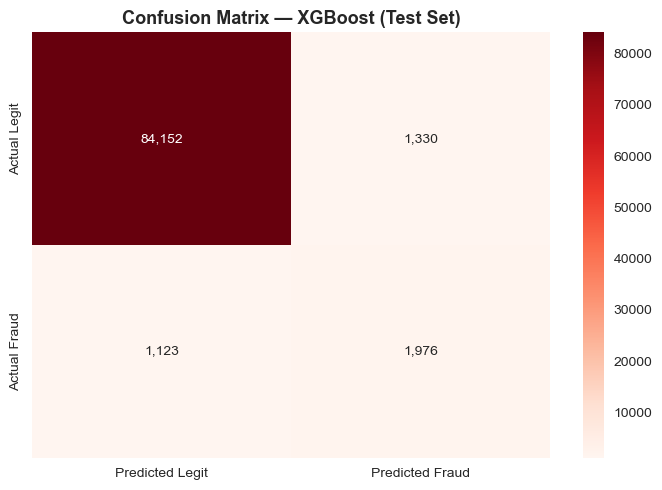


✅ Final Test Set Results
   AUC-ROC : 0.9395
   AUC-PR  : 0.6652

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99     85482
       Fraud       0.60      0.64      0.62      3099

    accuracy                           0.97     88581
   macro avg       0.79      0.81      0.80     88581
weighted avg       0.97      0.97      0.97     88581



In [24]:
# Evaluate on TEST SET — only done once
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt=',', cmap='Reds',
    xticklabels=['Predicted Legit', 'Predicted Fraud'],
    yticklabels=['Actual Legit',    'Actual Fraud']
)
plt.title(f'Confusion Matrix — {best_name} (Test Set)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

test_auc = roc_auc_score(y_test, y_test_prob)
test_apr = average_precision_score(y_test, y_test_prob)

print(f"\n✅ Final Test Set Results")
print(f"   AUC-ROC : {test_auc:.4f}")
print(f"   AUC-PR  : {test_apr:.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['Legitimate','Fraud'])}")

###  Feature Importance  

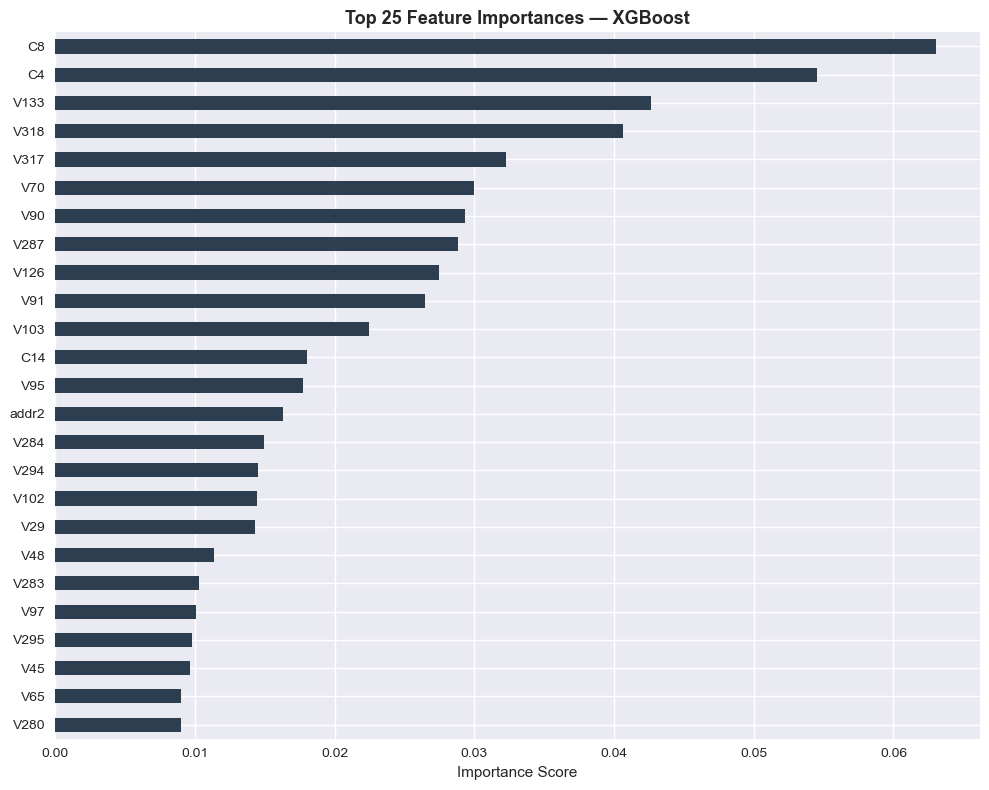

Top 10 most important features:
C8      0.063044
C4      0.054549
V133    0.042621
V318    0.040643
V317    0.032284
V70     0.029954
V90     0.029340
V287    0.028821
V126    0.027491
V91     0.026474


In [25]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train_res.columns
).sort_values(ascending=False)

top25 = importance.head(25)

plt.figure(figsize=(10, 8))
top25.plot(kind='barh', color='#2c3e50')
plt.xlabel('Importance Score')
plt.title(f'Top 25 Feature Importances — {best_name}',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
print(top25.head(10).to_string())

### Save Best Model

In [26]:
os.makedirs('../models', exist_ok=True)

# 1 — Save model
model_path = f'../models/best_model_{best_name.lower()}.pkl'
joblib.dump(best_model, model_path)

# 2 — Save feature column names
feature_cols = X_train_res.columns.tolist()
joblib.dump(feature_cols, '../models/feature_columns.pkl')

# 3 — Save test set predictions for dashboard
np.save('../models/y_test.npy',      y_test.values)
np.save('../models/y_test_prob.npy', y_test_prob)

# 4 — Save metrics JSON
metrics = {
    'model_name' : best_name,
    'auc_roc'    : round(test_auc, 4),
    'auc_pr'     : round(test_apr, 4),
    'threshold'  : 0.5,
    'total_features' : len(feature_cols),
}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ All files saved to ../models/")
print(f"   best_model_{best_name.lower()}.pkl")
print(f"   feature_columns.pkl")
print(f"   y_test.npy")
print(f"   y_test_prob.npy")
print(f"   metrics.json")
print(f"\nModel summary:")
for k, v in metrics.items():
    print(f"   {k:<20} : {v}")

✅ All files saved to ../models/
   best_model_xgboost.pkl
   feature_columns.pkl
   y_test.npy
   y_test_prob.npy
   metrics.json

Model summary:
   model_name           : XGBoost
   auc_roc              : 0.9395
   auc_pr               : 0.6652
   threshold            : 0.5
   total_features       : 233


## Summary

| Item | Detail |
|---|---|
| Models trained | XGBoost, LightGBM |
| Imbalance handling | SMOTE + RandomUnderSampler |
| Best model | Auto-selected by AUC-ROC |
| Saved files | model, features, metrics, predictions |

**Next Step → Phase 4: SHAP Explainability**   